In [9]:
# Used libraries included in workshop DNN & CNN
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import torch
import matplotlib.pyplot as plt

SEED = 64
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = 'cpu'

# Loading SM Data from .csv file.

In [10]:
# Function to load and parse the CSV data file by feature column, returning a pandas DataFrame
def load_data(filepath):   
    data = []

    # Read data from the CSV file
    # Open the file for reading
    with open(filepath, 'r') as f:
        # Iterate through each line in the file
        for line in f:

        # Split the line into parts using ';' as the delimiter
            parts = line.strip().split(';')

            # Get event info
            event_dict = {
                'Event ID': parts[0], # Unique event identifier
                'Process ID': parts[1], # Process identifier
                'Event Weight': parts[2], # Weight of the event
                'MET': parts[3], # Missing Transverse Energy
                'MET Phi': parts[4], # Azimuth Angle of MET
            }
            
            # Store all particles from the event
            particles = []

            # Each particle's info starts from index 5
            for i in range(5, len(parts)):
                
                # Check if the particle info is not empty
                if parts[i].strip():
                    # Split particle info by ','
                    part_info = parts[i].strip().split(',')


                    # Append particle info to the particles list
                    particles.append({
                        'Obj': part_info[0], # Obj OType
                        'E': float(part_info[1]), # Energy (MeV: [0,inf])
                        'P_t': float(part_info[2]), # Transverse Momentum (MeV: [0,inf])
                        'Eta': float(part_info[3]), # Pseudo-rapidity ([-inf,inf])
                        'Phi': float(part_info[4]), # Azimuth Angle ([-pi,pi])
                    })

            # Add particles list to the event dictionary
            event_dict['Particles'] = particles
            data.append(event_dict)

    return pd.DataFrame(data)

df_background = load_data('data/Proj2/background_chan2b_7.8.csv')

# Processing SM Datafile

In [11]:
# Process the DataFrame to extract features and truncate particles
def process_data(df, max_particles=8):
    processed_data = []

    # Iterate through each row in the DataFrame
    for _, row in df.iterrows():

        # Get the list of particles for the event
        particles = row['Particles']

        # Count different types of particles by checking the 'Obj' field for each particle in the event
        n_jets = sum(1 for p in particles if p['Obj'] == 'j')
        n_bjets = sum(1 for p in particles if p['Obj'] == 'b')
        n_electron = sum(1 for p in particles if p['Obj'] == 'e-, e+')
        n_muon = sum(1 for p in particles if p['Obj'] == 'mu-, mu+')
        n_photon = sum(1 for p in particles if p['Obj'] == 'g')

        # Sort particles by energy and truncate to keep only those beyond the 8th highest energy - instructed to do so
        particles_sorted = sorted(particles, key = lambda x: float(x['E']), reverse=True)
        # Truncate to max_particles - instructed to do so (keeps 8 highest energy particles)
        particles_trunc = particles_sorted[:max_particles]

        # Create a new row with the features
        new_row = {
            'Event ID': row['Event ID'],
            'Process ID': row['Process ID'],
            'Event Weight': float(row['Event Weight']),
            # Orders training variables
            'n_jets': n_jets,
            'n_bjets': n_bjets,
            'n_electron': n_electron,
            'n_muon': n_muon,
            'n_photon': n_photon,
            # Convet MET to log scale to prioritize differences in energy scale
            'MET': np.log1p(float(row['MET'])),
            'MET Phi': row['MET Phi'],
        }
# We use log1p to ensure that log(0) is handled properly
# With log1p, log1p(0) = log(1 + 0) = log(1) = 0

        # Add particle features (always 8 particles)
        for i in range(max_particles):
            if i < len(particles_trunc):
                particles = particles_trunc[i]
                new_row[f'E_{i+1}'] = np.log1p(float(particles['E']))
                new_row[f'P_t_{i+1}'] = np.log1p(float(particles['P_t']))
                new_row[f'Eta_{i+1}'] = float(particles['Eta'])
                new_row[f'Phi_{i+1}'] = float(particles['Phi'])
            # Pad with zeros if there are fewer than max_particles
            else:
                new_row[f'E_{i+1}'] = 0.0
                new_row[f'P_t_{i+1}'] = 0.0
                new_row[f'Eta_{i+1}'] = 0.0
                new_row[f'Phi_{i+1}'] = 0.0

        processed_data.append(new_row)
    
    return pd.DataFrame(processed_data)

# Process the background DataFrame
df_background_processed = process_data(df_background)

# Normalize the features using Min-Max scaling
scalar = MinMaxScaler()
# Select feature columns for scaling, excluding identifiers and weights
feature_cols = [col for col in df_background_processed.columns 
            if col not in ['Event ID', 'Process ID', 'Event Weight'] and not col.startswith('Obj_')]
df_background_processed[feature_cols] = scalar.fit_transform(df_background_processed[feature_cols])


# Display the first few rows of the processed DataFrame
df_background_processed.head(10)


,Event ID,Process ID,Event Weight,n_jets,n_bjets,n_electron,n_muon,n_photon,MET,MET Phi,...,Eta_6,Phi_6,E_7,P_t_7,Eta_7,Phi_7,E_8,P_t_8,Eta_8,Phi_8
0,5702564,z_jets,1.0,0.636364,0.000000,0.0,0.0,0.0,0.203157,0.027910,...,0.656386,0.223378,0.899412,0.916214,0.509688,0.543799,0.893885,0.907051,0.428767,0.918018
1,13085335,z_jets,1.0,0.090909,0.000000,0.0,0.0,0.0,0.205681,0.812250,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
2,74025,wtopbar,1.0,0.090909,0.166667,0.0,0.0,0.0,0.268951,0.312370,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
3,2419445,z_jets,1.0,0.181818,0.000000,0.0,0.0,0.0,0.124948,0.326246,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
4,43639,wtop,1.0,0.090909,0.166667,0.0,0.0,0.0,0.215573,0.336637,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
5,36857632,z_jets,1.0,0.181818,0.000000,0.0,0.0,0.0,0.512397,0.286942,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
6,93588,ww,1.0,0.181818,0.000000,0.0,0.0,0.0,0.034386,0.508656,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
7,3498243,z_jets,1.0,0.181818,0.000000,0.0,0.0,0.0,0.012991,0.371275,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
8,633,ww,1.0,0.181818,0.166667,0.0,0.0,0.0,0.028799,0.641336,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775
9,63525237,gam_jets,1.0,0.272727,0.000000,0.0,0.0,0.0,0.199745,0.151800,...,0.504521,0.500022,0.000000,0.000000,0.484603,0.499992,0.000000,0.000000,0.465163,0.499775


# Processing the BSM signal files:

In [12]:
# Load the BSM datasets
bsm_files = {
    'chacha_300_140': 'data/Proj2/chacha_cha300_neut140_chan2b.csv',
    'chacha_400_60': 'data/Proj2/chacha_cha400_neut60_chan2b.csv',
    'chacha600_200': 'data/Proj2/chacha_cha600_neut200_chan2b.csv',
    'chaneut_200_50': 'data/Proj2/chaneut_cha200_neut50_chan2b.csv',
    'chaneut_250_150': 'data/Proj2/chaneut_cha250_neut150_chan2b.csv',
    'gluino_1000_1': 'data/Proj2/gluino_1000.0_neutralino_1.0_chan2b.csv',
    'pp23mt_50': 'data/Proj2/pp23mt_50_chan2b.csv',
    'pp24mt_50': 'data/Proj2/pp24mt_50_chan2b.csv',
    'stlp_st1000': 'data/Proj2/stlp_st1000_chan2b.csv'
}

# Dictionary that holds the processed BSM datasets
bsm_datasets  = {}

# Process each BSM dataset
# For each BSM dataset, load, process, and scale the data (same as background)
for name, filepath in bsm_files.items():
    print(f"Processing BSM dataset: {name}")
    df_raw = load_data(filepath)
    df_processed = process_data(df_raw, max_particles = 8)
    df_processed[feature_cols] = scalar.transform(df_processed[feature_cols])

    bsm_datasets[name] = df_processed

Processing BSM dataset: chacha_300_140
Processing BSM dataset: chacha_400_60
Processing BSM dataset: chacha600_200
Processing BSM dataset: chaneut_200_50
Processing BSM dataset: chaneut_250_150
Processing BSM dataset: gluino_1000_1
Processing BSM dataset: pp23mt_50
Processing BSM dataset: pp24mt_50
Processing BSM dataset: stlp_st1000


# Splitting into training and validating sets:

The BSM data is not split, as we aren't training on possible 'Beyond SM' events. We are building a model to train on SM events, then recognize for events that don't follow the SM. So training on possible BSM events, would not trigger any flags when the model goes through the different BSM datasets.

In [13]:
# Split the background dataset into training and test sets, 80% train, 20% test
df_train, df_test = train_test_split(
    df_background_processed,
    test_size=0.2,
    train_size = 0.8,
    random_state=SEED, # Random seed for reproducibility
    shuffle=True # Shuffle the data before splitting
)

# Extract features for training and test sets
x_train = df_train[feature_cols].values
x_test = df_test[feature_cols].values
print(f"SM dataset: Training set: {x_train.shape} & Test set: {x_test.shape}")

# Extract features for BSM datasets
x_bsm = {}
for name, df in bsm_datasets.items():
    x_bsm[name] = df[feature_cols].values
    print(f"BSM dataset {name}: {x_bsm[name].shape}")

SM dataset: Training set: (272214, 39) & Test set: (68054, 39)
BSM dataset chacha_300_140: (665, 39)
BSM dataset chacha_400_60: (849, 39)
BSM dataset chacha600_200: (1205, 39)
BSM dataset chaneut_200_50: (1513, 39)
BSM dataset chaneut_250_150: (1376, 39)
BSM dataset gluino_1000_1: (58541, 39)
BSM dataset pp23mt_50: (3402, 39)
BSM dataset pp24mt_50: (8499, 39)
BSM dataset stlp_st1000: (13626, 39)


Verifying data between raw input and final processing.

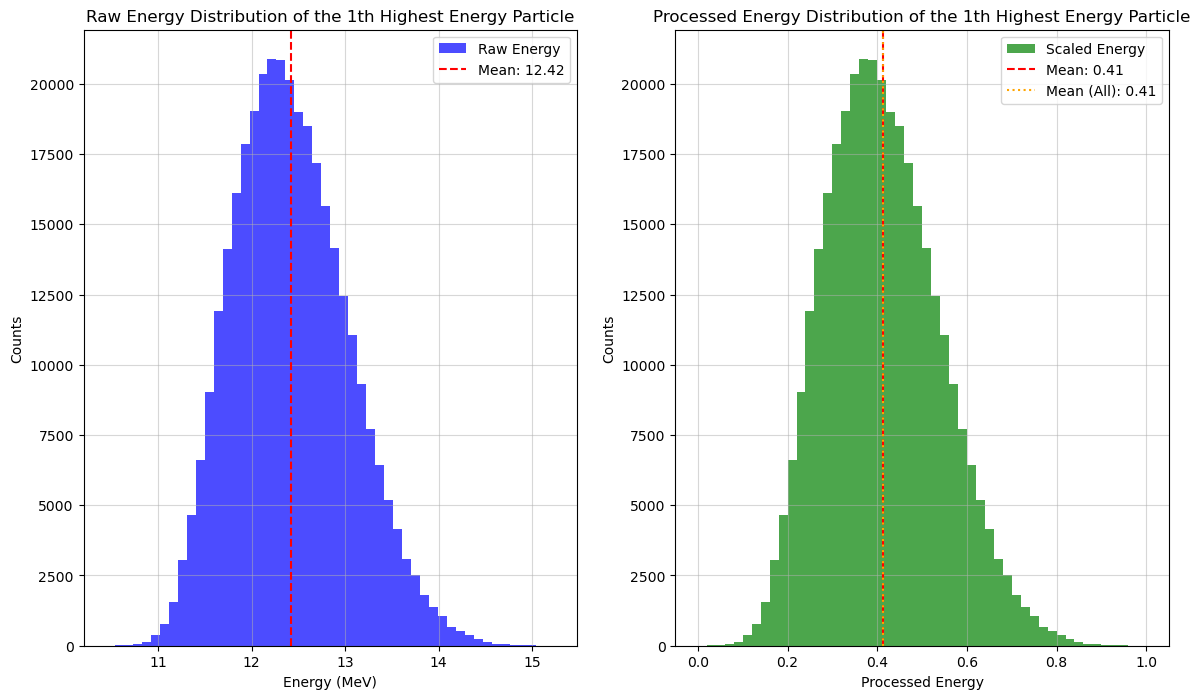

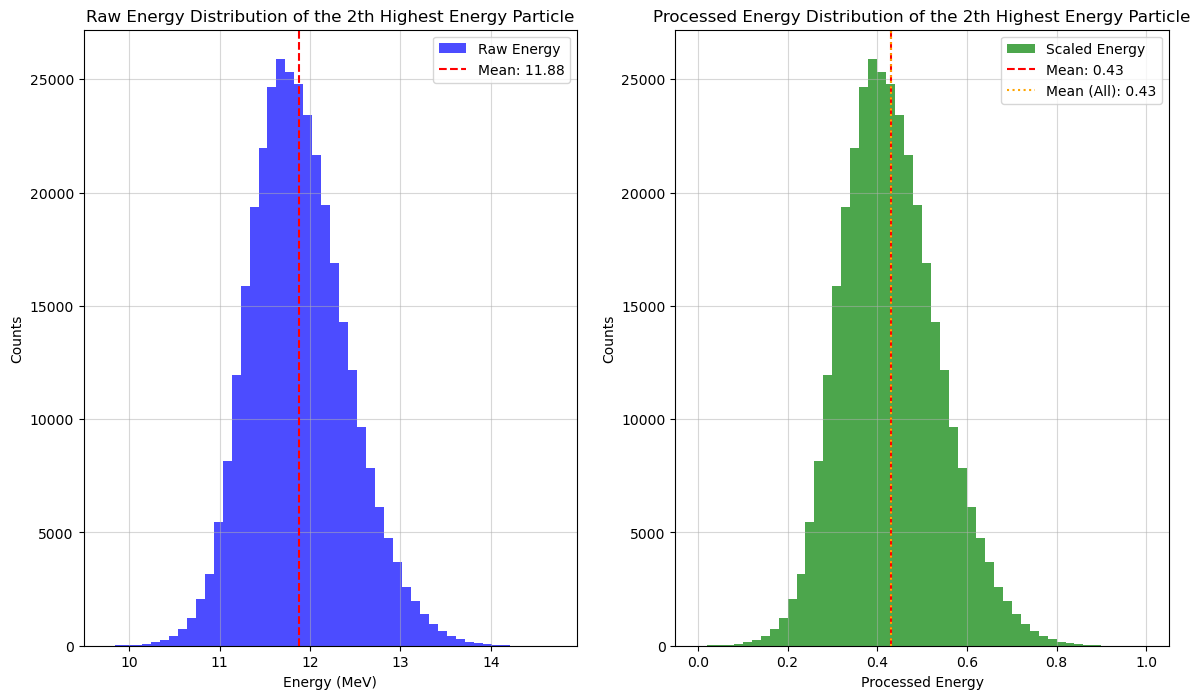

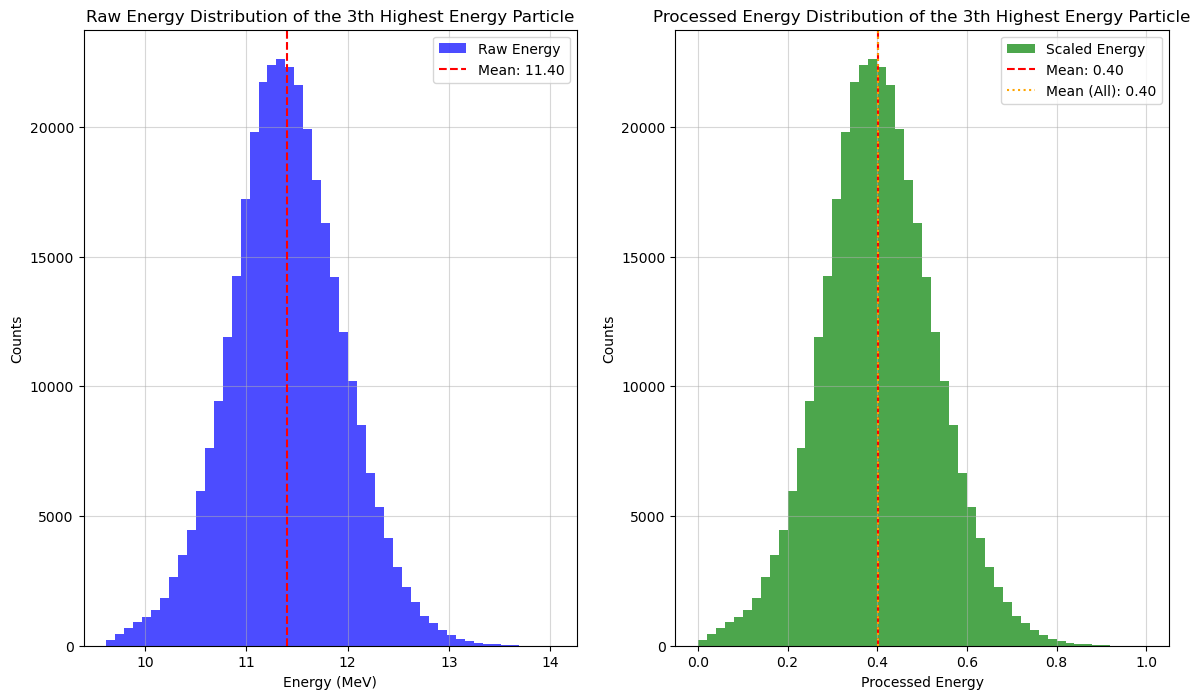

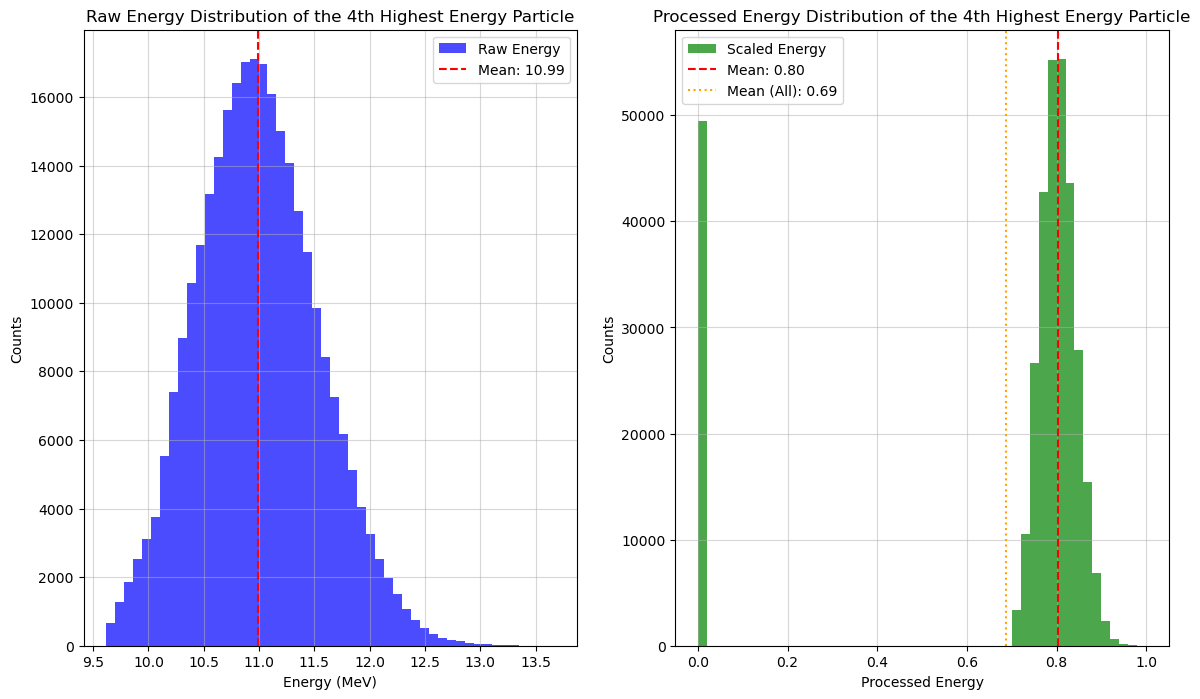

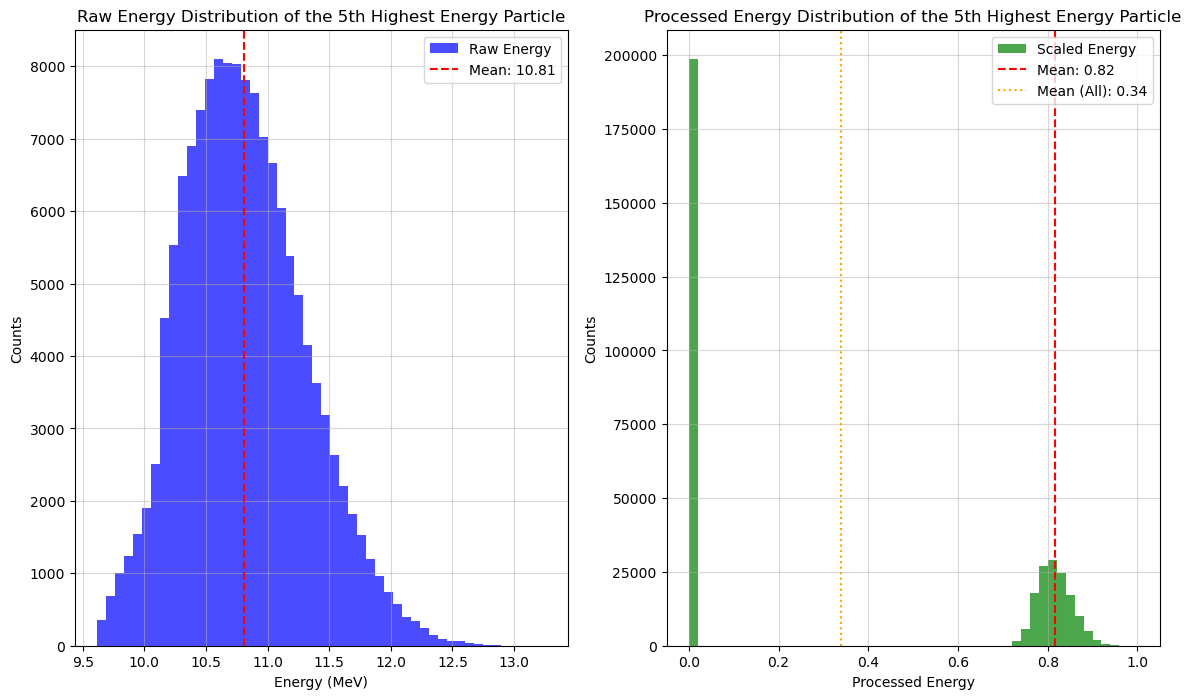

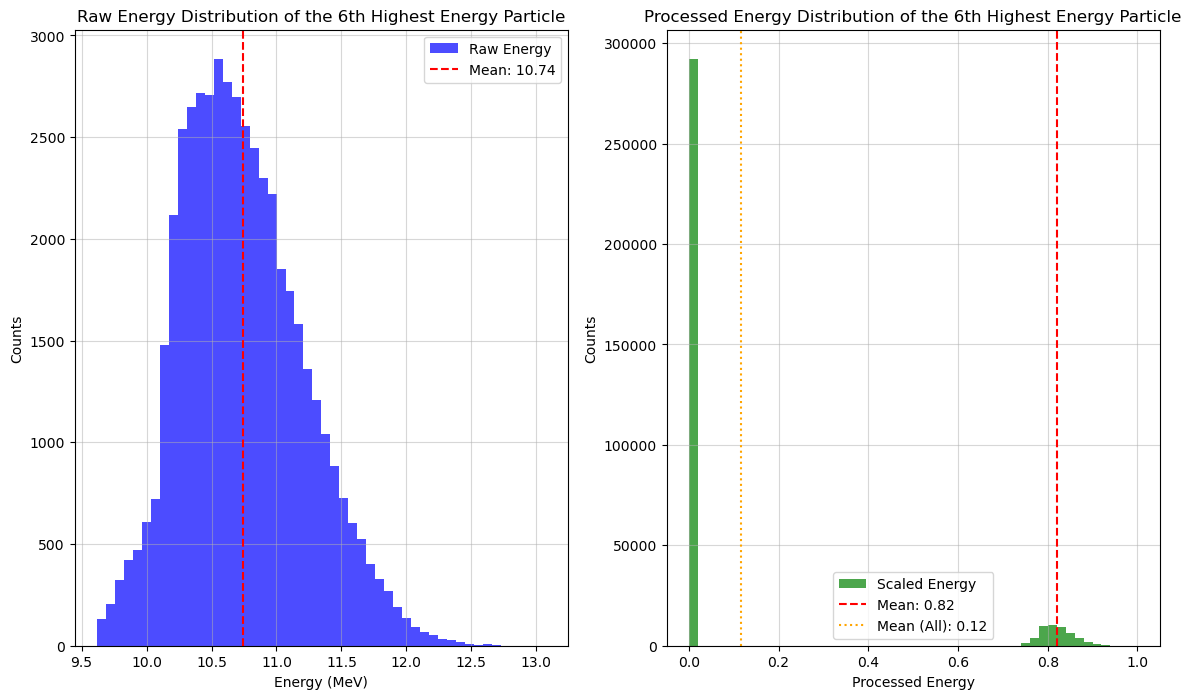

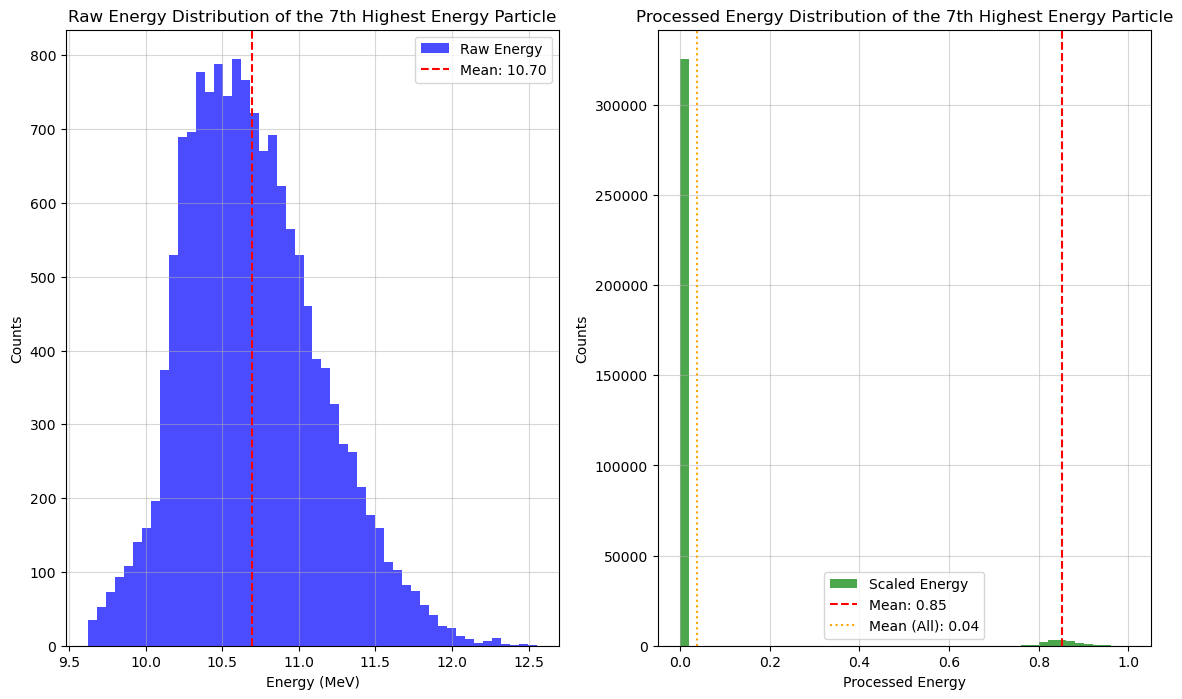

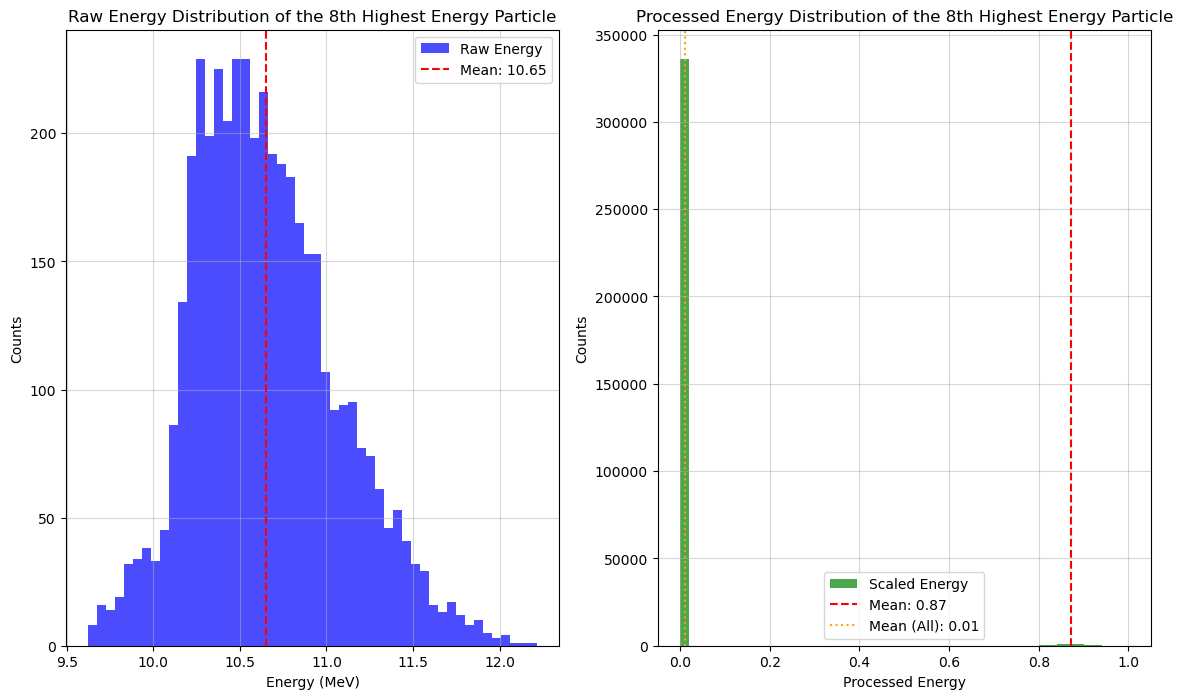

In [14]:
# Visualize the energy distributions of the ith highest energy particle before and after processing
# Done for validation of processing steps
for i in range(1,9):
    # Takes the raw energy values from the original dataframe
    raw_e = []
    for _, row in df_background.iterrows():
        particles = row['Particles']
        # Sort particles by energy
        particles_sorted = sorted(particles, key = lambda x: float(x['E']), reverse=True)
        if len(particles_sorted) >= i:
            #  Appends the raw energy
            raw_e.append(np.log1p(float(particles_sorted[i-1]['E'])))

    # Processed energy values from the processed dataframe
    e_col = f'E_{i}'
    # Includes all values, including zeros from padding
    scaled_e_all = df_background_processed[e_col].values
    # Only non-zero values
    scaled_e = scaled_e_all[scaled_e_all> 0]

    plt.figure(figsize = (14,8))

    # Plot raw energy distribution
    plt.subplot(1,2,1)
    plt.hist(raw_e, bins = 50, color = 'blue', alpha = 0.7, label = 'Raw Energy')
    plt.xlabel('Energy (MeV)')
    plt.ylabel('Counts')
    plt.title(f'Raw Energy Distribution of the {i}th Highest Energy Particle')
    plt.grid(True, alpha = 0.5)

    # Calculates the mean of the raw energy and plots it
    mean_e = np.mean(raw_e)
    plt.axvline(mean_e, color = 'red', linestyle = 'dashed', label = f'Mean: {mean_e:.2f}')
    plt.legend()

    # Plot processed energy distribution
    plt.subplot(1,2,2)
    plt.hist(scaled_e_all, bins = 50, color = 'green', alpha = 0.7, label = 'Scaled Energy')
    plt.xlabel('Processed Energy')
    plt.ylabel('Counts')
    plt.title(f'Processed Energy Distribution of the {i}th Highest Energy Particle')
    plt.grid(True, alpha = 0.5)

    # Calculates the means of the processed energies (both with zeros and without) and plots them
    mean_all = np.mean(scaled_e_all)
    mean_nonzero = np.mean(scaled_e)
    plt.axvline(mean_nonzero, color = 'red', linestyle = 'dashed', label = f'Mean: {mean_nonzero:.2f}')
    plt.axvline(mean_all, color = 'orange', linestyle = 'dotted', label = f'Mean (All): {mean_all:.2f}')
    plt.legend()

    plt.show()



The data looks to be correctly processed, taking the energies of the events log-transforming them and normalizing them with MinMaxScalar. 

As we progress from higher to lower energy particles the proprotion of zero-padding increases, as events with fewer then 8 particles are padded to maintain a fixed size. The remaining non-zero particles have high energies as only events with high amount of particles generate particles with 6-8 particles.In addition, MinMaxScalar scales them to the upper portion of the scaled range when there are a lot of zeros also processed.

# Autoencoder
Progress into training and testing the model across 30 epochs.

In [15]:
# Making the autoencoder to compress and reconstruct the data
class autoencoder(nn.Module):
    #Input dim = number of imput features (len(feature_cols))
    #Bottleneck dim = dimension of the latent space
    def __init__(self, input_dim, bottleneck_dim =8):
        super().__init__()

        #Defining the layers

        #Encoder layers - compresses to bottleneck
        self.fc1 = nn.Linear(input_dim, 32) # Starts with 39 features then goes to 32 dimensions
        self.fc2 = nn.Linear(32, 16) # Then to 16 dimensions
        self.fc3 = nn.Linear(16, bottleneck_dim) # Finally to 8

        #Decoder layers - reconstructs from bottleneck
        self.fc4 = nn.Linear(bottleneck_dim, 16) # Reconstructs from 8 to 16
        self.fc5 = nn.Linear(16, 32) # Then to 32
        self.fc6 = nn.Linear(32, input_dim) # Finally back to original input dimension (39)

        # Activation functions
        self.relu = nn.ReLU(inplace =True)  # ReLU for hidden layers
        self.sigmoid = nn.Sigmoid() # Sigmoid to ensure output is in [0,1] range

    #
    def forward(self, x):
        # Defines the dataflow through the network

        # Encoder - compresses to latent space
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x) # latent space

        # Decoder - reconstructs from latent space
        x = self.relu(self.fc4(x))
        x = self.relu(self.fc5(x))
        x = self.sigmoid(self.fc6(x)) #sigmoid for [0,1] output range

        return x
    
# Sets the input dimension as the number of features (39)
input_dim = len(feature_cols)
model = autoencoder(input_dim, bottleneck_dim = 8).to(device)
print(model)


autoencoder(
  (fc1): Linear(in_features=39, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=16, bias=True)
  (fc5): Linear(in_features=16, out_features=32, bias=True)
  (fc6): Linear(in_features=32, out_features=39, bias=True)
  (relu): ReLU(inplace=True)
  (sigmoid): Sigmoid()
)


In [16]:
# Testing the autoencoder with random input, making sure we reconstruct the same shape
test_input = torch.randn(5, input_dim)
print(f'Input shape: {test_input.shape}')
test_output = model(test_input)
print(f'Output shape: {test_output.shape}')

Input shape: torch.Size([5, 39])
Output shape: torch.Size([5, 39])


In [17]:
# Setting up the PyTorch tensors and DataLoaders for training and testing

# Convert numpy arrays to PyTorch tensors
x_train_tensor = torch.FloatTensor(x_train)
x_test_tensor = torch.FloatTensor(x_test)

# Create TensorDatasets
train_dataset = TensorDataset(x_train_tensor, x_train_tensor)
test_dataset = TensorDataset(x_test_tensor, x_test_tensor)

# Create DataLoaders and set batch size
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # No need to shuffle test data

# Make sure the dataset sizes are correct
print(f'Training set: {len(train_dataset)} events, Test set: {len(test_dataset)} events')

Training set: 272214 events, Test set: 68054 events


In [18]:
# Loss function and optimizer

# Mean Squared Error loss for reconstruction (same as workshop)
criterion = nn.MSELoss()

# Adam optimizer with learning rate 1e-4 (same as workshop)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)

In [19]:
# Early stopping parameters
val_loss, best_loss = np.inf, np.inf
patience = 5
epochs_no_improve = 0
warmup_epochs = 10 # Number of epochs to wait before starting early stopping checks

# Early stopping function in training loop
def early_stop():
    global best_loss, epochs_no_improve, warmup_epochs, val_loss

    # Check for improvement
    if val_loss < best_loss:
        best_loss = val_loss
        epochs_no_improve = 0

    # No improvement in this epoch 
    else:
        epochs_no_improve += 1

    # Warm-up period to allow initial training
    if warmup_epochs > 0:
        warmup_epochs -= 1
        return False
    
    # Check if patience has been exceeded, if so, trigger early stopping
    if epochs_no_improve >= patience:
        print(f'Early stopping triggered after {patience} epochs with no improvement.')
        return True
    return False

In [20]:
# Training Epoch
def train_epoch():
    model.train()
    train_loss = 0.0
    #   Iterate through the training data
    for data, _ in tqdm(train_loader):
        data = data.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(data)

        # Compute loss
        loss = criterion(outputs, data)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute loss
        train_loss += loss.item()

    # Calculate average loss over the epoch
    avg_loss = train_loss / len(train_loader)


    return avg_loss

In [21]:
# Validation Epoch
def val_epoch():
    model.eval()
    val_loss = 0.0
    #  Iterate through the validation data
    for data, _ in tqdm(test_loader):
        data = data.to(device)

        # Forward pass
        outputs = model(data)

        # Compute loss
        loss = criterion(outputs, data)
        val_loss += loss.item()
    # Calculate average loss over the epoch
    avg_loss = val_loss / len(test_loader)

    return avg_loss

In [22]:
# Number of training epochs (moderate)
epochs = 30

train_losses = []
val_losses = []

for epoch in range(epochs):
    # Check for early stopping
    if early_stop():
        print(f"Stopping Training Early at epoch: {epoch+1}")
        break

        # Training and validation for the epoch
    model.train()
    train_loss = train_epoch()
        
    with torch.no_grad():
        val_loss = val_epoch()

    # Save average losses for each epoch
    avg_train_loss = train_loss
    avg_val_loss = val_loss

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Prints epoch progress and losses for that epoch
    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')

model.eval()

    

  0%|          | 0/2127 [00:00<?, ?it/s]

100%|██████████| 532/532 [00:00<00:00, 2347.75it/s]


Epoch [1/30], Train Loss: 0.043000, Val Loss: 0.022626


100%|██████████| 532/532 [00:00<00:00, 2501.22it/s]


Epoch [2/30], Train Loss: 0.022025, Val Loss: 0.021639


...

100%|██████████| 532/532 [00:00<00:00, 2233.64it/s]


Epoch [29/30], Train Loss: 0.006463, Val Loss: 0.006420


100%|██████████| 532/532 [00:00<00:00, 2804.69it/s]

Epoch [30/30], Train Loss: 0.006405, Val Loss: 0.006368


autoencoder(
  (fc1): Linear(in_features=39, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=16, bias=True)
  (fc5): Linear(in_features=16, out_features=32, bias=True)
  (fc6): Linear(in_features=32, out_features=39, bias=True)
  (relu): ReLU(inplace=True)
  (sigmoid): Sigmoid()
)

# Model Evaluation
Now we go on to test the model on its performance with SM and BSM data with efficiencies and anomaly scores.

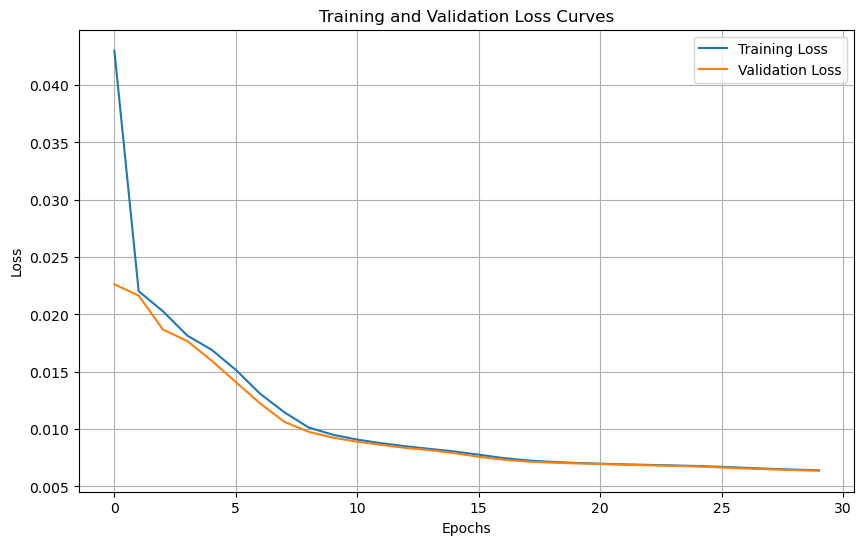

In [23]:
# Plotting the training and validation loss curves

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid()
plt.show()


The Loss curves indicate a well-performing model that doesn't suffer from overtraining, as the validation and training curves follow each other as they decrease with every ongoing epoch. 

In [24]:
# Function to compute reconstruction errors for a given dataset
def recon_errors(model, data_tensor, batch_size = 128):
    model.eval()
    recon_errors = []

    dataset = TensorDataset(data_tensor, data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Iterate through the data loader
    with torch.no_grad():
        for data, _ in tqdm(loader):
            data = data.to(device)

            # Reconstruct the input data
            reconstructed = model(data)

            # Compute reconstruction error for each sample (uses MSE, but saves as an array)
            batch_errors = torch.mean((data - reconstructed) ** 2, dim=1)
            # Adds batch errors to list in numpy format
            recon_errors.extend(batch_errors.numpy())

    return np.array(recon_errors)

# Compute reconstruction errors for the SM test dataset
print("SM Test Dataset...")
sm_errors = recon_errors(model, x_test_tensor, batch_size=128)

# Compute reconstruction errors for each BSM dataset
bsm_errors = {}
for name, df in bsm_datasets.items():
    print(f"BSM: {name}...")
    x_bsm_tensor = torch.FloatTensor(df[feature_cols].values)
    bsm_errors[name] = recon_errors(model, x_bsm_tensor, batch_size=128)



SM Test Dataset...


100%|██████████| 532/532 [00:00<00:00, 2589.99it/s]


BSM: chacha_300_140...


100%|██████████| 6/6 [00:00<00:00, 1823.21it/s]


BSM: chacha_400_60...


...

100%|██████████| 27/27 [00:00<00:00, 2604.98it/s]


BSM: pp24mt_50...


100%|██████████| 67/67 [00:00<00:00, 2450.01it/s]


BSM: stlp_st1000...


100%|██████████| 107/107 [00:00<00:00, 2783.92it/s]


In [25]:
# Efficiencies calculation
def calc_scores(sm_errors, bsm_errors, thresholds):
   # Saving efficiencies for BSM and SM
   signal_eff = []
   background_eff = []

    # Calculate efficiencies at each threshold
   for threshold in thresholds:
        # Signal efficiency: fraction of BSM events above threshold
        sig_eff = np.sum(bsm_errors > threshold) / len(bsm_errors)
        signal_eff.append(sig_eff)

        # Background efficiency: fraction of SM events above threshold
        bg_eff = np.sum(sm_errors > threshold) / len(sm_errors)
        background_eff.append(bg_eff)

   return np.array(signal_eff), np.array(background_eff)

# Determine thresholds based on min and max reconstruction errors in all datasets
total_errors = np.concatenate([sm_errors] + list(bsm_errors.values()))
min_error = np.min(total_errors)
max_error = np.max(total_errors)
thresholds = np.linspace(min_error, max_error, 100)

# Calculate efficiencies for each BSM dataset
efficiencies = {}

for name, bsm_error in bsm_errors.items():
    sig_eff, bg_eff = calc_scores(sm_errors, bsm_error, thresholds)
    efficiencies[name] = {
        'signal_efficiency': sig_eff, # True Positive Rate
        'background_efficiency': bg_eff, # False Positive Rate
        'thresholds': thresholds       
    }

In [26]:
# Summary statistics of reconstruction errors for SM and BSM datasets
print('SM reconstruction error stats:')
print(f" Shape: {sm_errors.shape}")
print(f" Mean: {np.mean(sm_errors)}")

print('\nBSM reconstruction error stats:')
for name, bsm_error in bsm_errors.items():
    print(f' Dataset: {name}')
    print(f"  Shape: {bsm_error.shape}")
    print(f"  Mean: {np.mean(bsm_error)}")

    # Difference in mean reconstruction error between BSM and SM
    mean_diff = np.mean(bsm_error) - np.mean(sm_errors)
    print(f"  Mean Difference from SM: {mean_diff}\n")

SM reconstruction error stats:
 Shape: (68054,)
 Mean: 0.006367737893015146

BSM reconstruction error stats:
 Dataset: chacha_300_140
  Shape: (665,)
  Mean: 0.007168282754719257
  Mean Difference from SM: 0.0008005448617041111

 Dataset: chacha_400_60
  Shape: (849,)
  Mean: 0.00882093794643879
  Mean Difference from SM: 0.002453200053423643

 Dataset: chacha600_200
  Shape: (1205,)
  Mean: 0.009278258308768272
  Mean Difference from SM: 0.002910520415753126

 Dataset: chaneut_200_50
  Shape: (1513,)
  Mean: 0.007134892512112856
  Mean Difference from SM: 0.0007671546190977097

 Dataset: chaneut_250_150
  Shape: (1376,)
  Mean: 0.007128202822059393
  Mean Difference from SM: 0.0007604649290442467

 Dataset: gluino_1000_1
  Shape: (58541,)
  Mean: 0.02756805159151554
  Mean Difference from SM: 0.021200314164161682

 Dataset: pp23mt_50
  Shape: (3402,)
  Mean: 0.0070360638201236725
  Mean Difference from SM: 0.0006683259271085262

 Dataset: pp24mt_50
  Shape: (8499,)
  Mean: 0.008714462

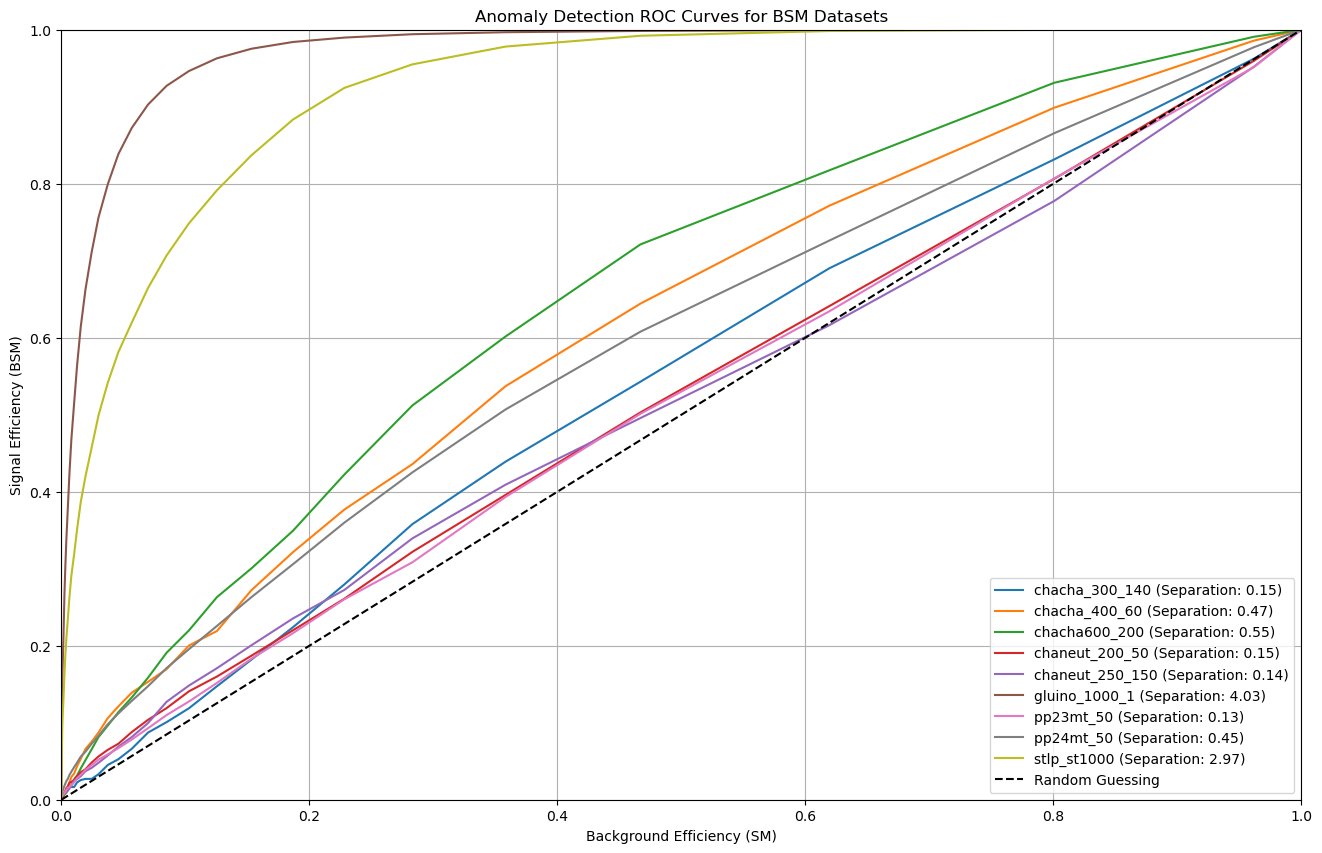

In [27]:
# Plot of ROC Curves (Receiver Operating Characteristic)
plt.figure(figsize=(16, 10))
for idx, (name, eff) in enumerate(efficiencies.items()):
    # Calculate mean reconstruction error for BSM dataset
    bsm_mean = np.mean(bsm_errors[name])
    # Calculate separation metric from mean reconstruction errors
    separation = (bsm_mean - np.mean(sm_errors))/np.std(sm_errors)

    # Plot ROC curve for the BSM dataset
    plt.plot(eff['background_efficiency'],
             eff['signal_efficiency'],
             label=f'{name} (Separation: {separation:.2f})')

# Plot random guessing line - diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing') 
plt.xlabel('Background Efficiency (SM)')
plt.ylabel('Signal Efficiency (BSM)')
plt.title('Anomaly Detection ROC Curves for BSM Datasets')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

The two signals that show significant separation from the standard model are the Gluino and Stlp, with high deviations (~$4\sigma$ and ~$3\sigma$, respectively). 

The ROC curve plots the trade-off between correctly identifying BSM events vs incorrectly flagging SM events. 
    The x-axis being false positive rate (background efficiency):
    
$ x = \frac {\text{false positive}} {\text{false positive + true negative}} $

The y-axis is the true positive rate (signal efficiency) with the fraction of BSM events above the threshold.
    
 For example, the point (0.1, 0.75) means that if we set 10% of SM events to be flagged as anomalous (false alarms), then 75% of the BSM models would be correctly identified as anomalous. The diagonal is where the number of true positive = false positives, basically random guessing between events.

So signals with significant deviation ($>2\sigma$) show higher deviation from standard model, and are curves well above the diagonal. The curves are traced out across all threshold values corresponding 100 values across the minimum and maximum reconstructed errors in both SM and BSM datasets. A low threshold (~0.001), where almost all events exceed it leads to a point around (1.0, 1.0). While a high threshold (~0.050)corresponds to no events at a point such as (0.0, 0.0) where no events are above the threshold.

Looking specifically at the results, a signal with high separation (Gluinos) at a 0.01 (1% false rate) ~ 0.75 (75% signal efficiency). Basically, setting a threshold to flag 1% of SM events as anomalous would set 75% of Gluino events as anomalous.

In contrast, looking at the chacha_300 curve, with a separation of ~$~0.1\sigma$, a threshold that flags 40% of SM events would flag ~45% of charigno events, not significant deviation (0.4,0.45). This is shown graphically as its curve lies very close to the diagonal, with the autoencoder recognizing the BSM model as SM-like.

Now to get an anomaly score, we have to fix a threshold that will return a number of events back as being anomalous. To do so we select a FPR (desired false positive rate) that we set to ~1% using the inverse cumulative functions with np.quantile.

In [28]:
# Set threshold based on desired False Positive Rate (FPR)
def fpr(sm_errors, target_fpr = 0.01):
    # Uses the PPF (percent point function) to determine threshold for given FPR (ex. what height in man is considered 1 in a million).
    # This case we give it all SM errors, and want it to find the threshold where only 1% of SM errors are above it.
    threshold = np.quantile(sm_errors, 1 - target_fpr)
    return threshold

threshold = fpr(sm_errors, target_fpr = 0.01)

# Summarize anomalies detected in SM dataset
anomaly_summary = {}
# Identify anomalies in SM dataset based on threshold
sm_anomaly_flags = sm_errors > threshold

# Store summary information
anomaly_summary['SM'] = {
    'Total' : len(sm_errors),
    'Anomalies' : np.sum(sm_anomaly_flags),
    'Errors': sm_errors,
    'Flags': sm_anomaly_flags
}
# Checks to see if flagged events are ~1% of total
print(f"SM Background:")
print(f" Total Events: {anomaly_summary['SM']['Total']}")
print(f" Flagged Events: {anomaly_summary['SM']['Anomalies']}")

SM Background:
 Total Events: 68054
 Flagged Events: 680


In [29]:
# Now for BSM datasets
for name, errors in bsm_errors.items():
    anomaly_flags = errors > threshold

    anomaly_summary[name] = {
        'Total': len(errors),
        'Anomalies': np.sum(anomaly_flags),
        'Errors': errors,
        'Flags': anomaly_flags
    }

In [30]:
# Making a dataframe for easier analysis of anomalies

anomaly_df = pd.DataFrame(anomaly_summary).T
# Highlights the number of anomalies for each dataset
anomaly_df = anomaly_df[['Total', 'Anomalies']]
# Calculate anomaly rate as a percentage of the total dataset
anomaly_df['Anomaly Rate (%)'] = (anomaly_df['Anomalies'] / anomaly_df['Total']) * 100
anomaly_df

,Total,Anomalies,Anomaly Rate (%)
SM,68054,680,0.999207
chacha_300_140,665,11,1.654135
chacha_400_60,849,29,3.415783
chacha600_200,1205,32,2.655602
chaneut_200_50,1513,39,2.57766
chaneut_250_150,1376,32,2.325581
gluino_1000_1,58541,29775,50.861789
pp23mt_50,3402,76,2.23398
pp24mt_50,8499,353,4.15343
stlp_st1000,13626,4303,31.579334


The anomaly score is the anomaly rate for each model.

# Testing which SM events are flagged as anomalous:

In [31]:
# uses np.where to return the index where the given condition is met (sm_errors > threshold)
anomalous_indices = np.where(sm_errors > threshold)[0]
# Get the corresponding event indices from the original dataframe
test_indices = df_background_processed.index[-len(x_test):]
# Finds the original indices of the anomalous events in the test set
anomalous_test_indices = test_indices[anomalous_indices]

# Analyze the Process IDs of the flagged anomalous SM events
processed_anomalous_events = df_background_processed.loc[anomalous_test_indices, 'Process ID'].value_counts()
print("Anomalous SM Events by Process ID:")
print(processed_anomalous_events)


Anomalous SM Events by Process ID:
Process ID
z_jets        314
ttbar          99
wtopbar        83
wtop           63
gam_jets       58
ww             45
njets           7
zw              5
Zgam            3
Wgam            2
ttbarHiggs      1
Name: count, dtype: int64


In [32]:
# Making dataframe for easier analysis of anomalous events
# Analyze feature distributions of the flagged anomalous SM events

# Find data corresponding to anomalous indices
anomalous_data = x_test[anomalous_indices]
# Gets average values for anomalous SM events
anom_met_avg = anomalous_data[:, feature_cols.index('MET')].mean()
anom_phi_avg = anomalous_data[:, feature_cols.index('MET Phi')].mean()
anom_recon_error_avg = sm_errors[anomalous_indices].mean()
anom_avg_jet_count = anomalous_data[:, feature_cols.index('n_jets')].mean() 
anom_avg_bjet_count = anomalous_data[:, feature_cols.index('n_bjets')].mean() 
anom_avg_e_count = anomalous_data[:, feature_cols.index('n_electron')].mean()
anom_avg_mu_count = anomalous_data[:, feature_cols.index('n_muon')].mean()
anom_sm_count = len(anomalous_indices)
anom_sm_rate = (anom_sm_count / len(sm_errors)) * 100
 
# Now for normal SM events (not flagged as anomalies - below threshold)
normal_indices = np.where(sm_errors <= threshold)[0]
normal_data = x_test[normal_indices]
# Gets average values for normal SM events for comparison
norm_met_avg = normal_data[:, feature_cols.index('MET')].mean()
norm_phi_avg = normal_data[:, feature_cols.index('MET Phi')].mean()
norm_recon_error_avg = sm_errors[normal_indices].mean()
norm_avg_jet_count = normal_data[:, feature_cols.index('n_jets')].mean() # finds average number of jets
norm_avg_bjet_count = normal_data[:, feature_cols.index('n_bjets')].mean() # finds average number of b-jets
norm_avg_e_count = normal_data[:, feature_cols.index('n_electron')].mean() # finds average number of electrons
norm_avg_mu_count = normal_data[:, feature_cols.index('n_muon')].mean() # finds average number of muons
norm_sm_count = len(normal_indices)
norm_sm_rate = (norm_sm_count / len(sm_errors)) * 100

# Panda Dataframe with all anomaly information
anomaly_pd = pd.DataFrame({
    'Feature': ['MET', 'MET Phi', 'Reconstruction Error', 'n_jets', 'n_bjets', 'n_electron', 'n_muon', 'Total Events', 'Rate (%)'],
    'Normal SM Average': [norm_met_avg, norm_phi_avg, norm_recon_error_avg, norm_avg_jet_count, norm_avg_bjet_count, norm_avg_e_count, norm_avg_mu_count, norm_sm_count, norm_sm_rate],
    'Anomalous SM Average': [anom_met_avg, anom_phi_avg, anom_recon_error_avg, anom_avg_jet_count, anom_avg_bjet_count, anom_avg_e_count, anom_avg_mu_count, anom_sm_count, anom_sm_rate]
})

# Two BSM models to analyze anomalies for
bsm_models_anom = ['gluino_1000_1', 'stlp_st1000'] # These were the only two with significant anomalies

# Now onto BSM anomaly averages:
for name in bsm_models_anom:
    # Find data corresponding to anomalous indices
    bsm_data = bsm_datasets[name][feature_cols].values
    bsm_errors_for_dataset = bsm_errors[name]
    # Locate indices of anomalies in the BSM dataset
    bsm_anomalous_indices = np.where(bsm_errors_for_dataset > threshold)[0]
    
    # If no anomalies detected, fill with zeros
    if len(bsm_anomalous_indices) == 0:
        anomaly_pd[f'{name} Average'] = 0
        continue

    # Get the anomalous data
    bsm_anomalous_data = bsm_data[bsm_anomalous_indices]
    
    # Calculate average values for anomalous BSM events
    bsm_met_avg = bsm_anomalous_data[:, feature_cols.index('MET')].mean()
    bsm_phi_avg = bsm_anomalous_data[:, feature_cols.index('MET Phi')].mean()
    bsm_recon_error_avg = bsm_errors_for_dataset[bsm_anomalous_indices].mean()
    bsm_avg_jet_count = bsm_anomalous_data[:, feature_cols.index('n_jets')].mean()
    bsm_avg_bjet_count = bsm_anomalous_data[:, feature_cols.index('n_bjets')].mean()
    bsm_avg_e_count = bsm_anomalous_data[:, feature_cols.index('n_electron')].mean()
    bsm_avg_mu_count = bsm_anomalous_data[:, feature_cols.index('n_muon')].mean()
    bsm_count = len(bsm_anomalous_indices)
    bsm_rate = (bsm_count / len(bsm_data)) * 100

    # Add BSM anomaly averages to the dataframe
    anomaly_pd[f'{name} Average'] = [bsm_met_avg, bsm_phi_avg, bsm_recon_error_avg, bsm_avg_jet_count, bsm_avg_bjet_count, bsm_avg_e_count, bsm_avg_mu_count, bsm_count, bsm_rate]
    

anomaly_pd.round(3) # Round for easier viewing


,Feature,Normal SM Average,Anomalous SM Average,gluino_1000_1 Average,stlp_st1000 Average
0,MET,0.180,0.223,0.485,0.548
1,MET Phi,0.500,0.465,0.483,0.489
2,Reconstruction Error,0.006,0.031,0.035,0.036
3,n_jets,0.171,0.430,0.470,0.380
4,n_bjets,0.092,0.132,0.432,0.214
5,n_electron,0.000,0.000,0.000,0.000
6,n_muon,0.000,0.000,0.000,0.000
7,Total Events,67374.000,680.000,29775.000,4303.000
8,Rate (%),99.001,0.999,50.862,31.579


Looking at the average anomalous vs normal features, there are noticeable differences in MET (missing traverse energy) and the number of jets produced. These features (as they have clear distinction to the SM averages) may have led the model to have a difficult time in reconstructing, flagging them as anomalous.

# Limitations
In terms of limitations, truncating the particles loses information for complex events with many particles. 
The employment of a regular autoencoder vs a VAE could undermine some patterns in the compressed latent space.
The padding of zeros may have created artificial patterns for the model to train on.

# Improvements
Given more time, a VAE could have been implemented, using the KL divergence to better structure the latent space. I would have also liked to implement an accuracy curve for the model to see how well it improved for each epoch. In addition, a look into the average energies of average jets produced in the anomalous events and comparing it to the the normal (not anomalous) SM data could have given a more clear image on how the model flags the events.

# Issues
In terms of issues, I had a hard time addressing the efficiencies, coming up with a way to define what are anomalous events given a set threshold. 
Ended up using an ROC curve (shown in DSPipeline) to get a better idea of the threshold selection is done and proceeded with a 1% false positive rate in this case. This was done as the ROC shows great separation for the Gluino and Stlp models at 1% FPR. 

In addition, I had a hard time optimizing the encoder and decoder architecture. Initially I ran into the issue of naively copying the Autoencoder example in "AE_example_mnist.ipynb" where the first layer decrases the images to 64 dimensions. In this case with LHC data and 39 feature columns, having the input dimensions being 39 and the encoder 'decreasing' it to 64 dimensions made no sense. After fixing that, I played around with different layers dimensions, initially set to 39 -> 28 -> 16 -> 8 and back, but found that the training and validating loss was better for a 39 -> 32 -> 16 -> 8 enocder architecture. Given more time, more experimenting and optimizing could increase the model perfromance, specifically with including batch normalization.